In the list add proper known monomners for testing reactions

In [42]:
sample_smiles = [
            "O=C(Cl)CCCCCO"       
            ]

In [ ]:
from rdkit import Chem
for s in sample_smiles:
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        raise ValueError(f"SMILES '{s}' is invalid (RDKit could not parse it).")


Validating SMILES: O=C(Cl)CCCCCO


Define your required monomers functionality 

In [43]:
monomers = {
    "hydroxy_acyl_chlorides_monomer": {
        "functionality_type": "di_different",
        "smarts_1": "[OX2H1;!$(OC=*):1]",
        "smarts_2": "[CX3:2](=[O])[Cl,Br,I,OX2H1]",
        "group_name": "hydroxy_carboxylic_acid"
}
}


In [51]:
for funct in monomers.values():
    functionality_type = funct["functionality_type"]
    if functionality_type is None:
        raise ValueError("Functionality type is missing.")
    if functionality_type not in ["di_identical", "di_different", "mono", "vinyl"]:
        raise ValueError(f"Functionality type '{functionality_type}' is invalid.")
    if "smarts_1" not in funct:
        raise ValueError("Missing 'smarts_1' must be provided.")
    smart_1 = funct.get("smarts_1")
    if Chem.MolFromSmarts(smart_1) is None:
        raise ValueError(f"'smarts_1' '{smart_1}' is invalid.")
    if functionality_type == "di_different":
        smart_2 = funct.get("smarts_2")
        if smart_2 is None:
            raise ValueError("Missing 'smarts_2' for 'di_different' functionality type.")
        if Chem.MolFromSmarts(smart_2) is None:
            raise ValueError(f"'smarts_2' '{smart_2}' is invalid.")
    if "group_name" not in funct:
        raise ValueError("Missing 'group_name' must be provided.")
    group_name = funct.get("group_name")
    if not isinstance(group_name, str) or not group_name.strip():
        raise ValueError(f"'group_name' '{group_name}' is invalid.")
    print(f"{group_name} definitions are valid.")
    

hydroxy_carboxylic_acid definitions are valid.


Testing Function Block

In [52]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

def validate_functional_group(sample_smiles: list[str], monomers: dict [str, dict [str, str]]) -> bool:
    # Placeholder for validation logic
    for monomer in sample_smiles:
        mol = Chem.MolFromSmiles(monomer)
        AllChem.AddHs(mol)
        for funtionality in monomers.values():
            if funtionality["functionality_type"] == "di_different":
                smarts_1 = Chem.MolFromSmarts(funtionality["smarts_1"])
                smarts_2 = Chem.MolFromSmarts(funtionality["smarts_2"])
                if mol.HasSubstructMatch(smarts_1) and mol.HasSubstructMatch(smarts_2):
                    print(f"Monomer {monomer} matches functionality {funtionality['group_name']}")
                    print("Different functional passed.")
                    hightlighted_atoms_1 = mol.GetSubstructMatch(smarts_1)
                    hightlighted_atoms_2 = mol.GetSubstructMatch(smarts_2)
                    atoms_to_highlight = list(hightlighted_atoms_1) + list(hightlighted_atoms_2)
                    AllChem.AddHs(mol)
                    return mol, atoms_to_highlight
    raise ValueError("No matching functional group found.")


           

Test the detect_reactions function

Monomer O=C(Cl)CCCCCO matches functionality hydroxy_carboxylic_acid
Different functional passed.


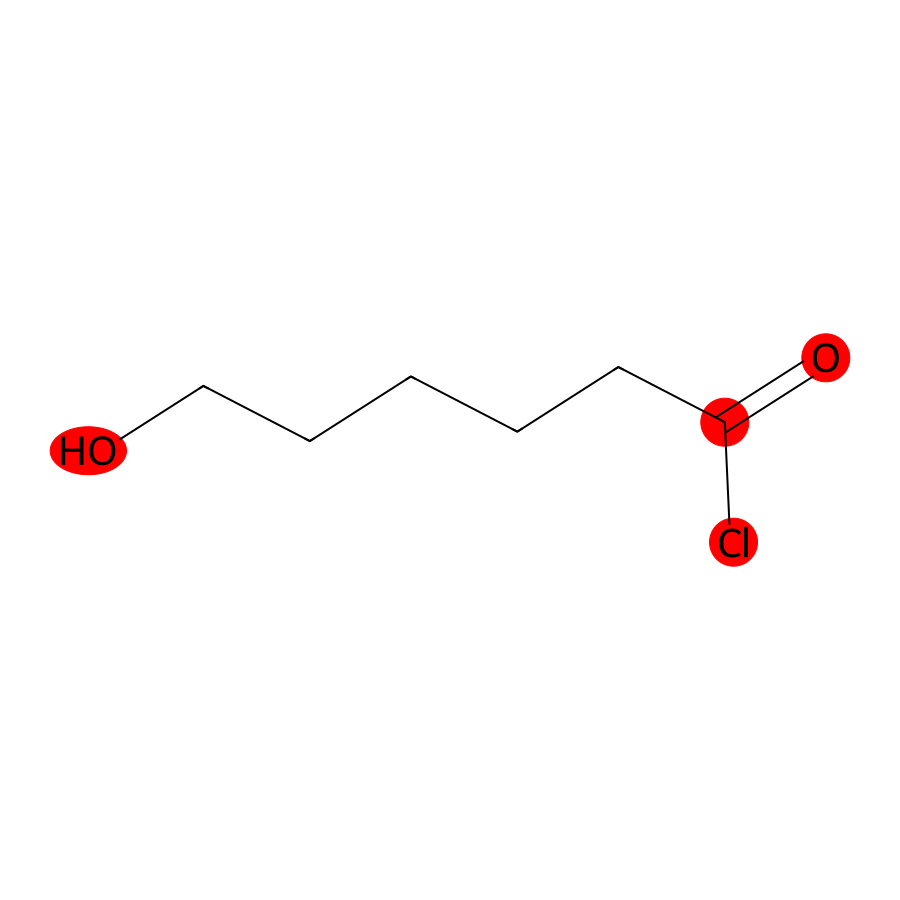

In [53]:
mol, atoms_to_highlight = validate_functional_group(sample_smiles, monomers)
from rdkit.Chem import Draw
img = Draw.MolToImage(
    mol,
    size=(900, 900),
    highlightAtoms=atoms_to_highlight,
    highlightColor=(1, 0, 0),
)
img.save("highlighted_molecule.png")
img


In [ ]:
reactions_definitions = {
    "Hydroxy Carboxylic Acid Polycondensation(Polyesterification)": {
        "same_reactants": True,
        "reactant_1": "hydroxy_carboxylic_acid",
        "product": "polyester_chain",
        "delete_atom": True,
        "reaction": "[O;!$(OC=*):1]-[H:3].[CX3:2](=[O:5])[OX2H1:4]>>[OX2:1]-[CX3:2](=[O:5]).[O:4]-[H:3]",
        "reference": {"smarts": "https://pubs.acs.org/doi/10.1021/acs.jcim.3c00329",
                      "reaction_and_mechanism": ["https://pubs.acs.org/doi/10.1021/ed048pA734.1", 
                                                 "https://pubs.acs.org/doi/10.1021/ed073pA312"]}
    }
}

In [ ]:
for reaction in reactions_definitions.values():
    reaction_smarts = reaction.get("reaction")
    same_reactants = reaction.get("same_reactants")
    
    reactant_1 = reaction.get("reactant_1")
    product = reaction.get("product")
    delete_atom = reaction.get("delete_atom")
    reference = reaction.get("reference")
    if same_reactants is None:
        raise ValueError("Same reactants flag is missing.")
    if reactant_1 is None:
        raise ValueError("Reactant 1 information is missing.")
    if reaction_smarts is None:
        raise ValueError("Reaction SMARTS is missing.")
    if Chem.ReactionFromSmarts(reaction_smarts) is None:
        raise ValueError(f"Reaction SMARTS '{reaction_smarts}' is invalid.")
    if not same_reactants:
        reactant_2 = reaction.get("reactant_2")
    if reference is None:
        print("Warning: Reference information is missing.")
    print("Reaction SMARTS is valid.")